<a href="https://colab.research.google.com/github/marcoscalera/am_turma5_prova/blob/main/MarcosCalera_am_t5_prova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Classificação da Dependência Administrativa da Escola [Marcos Calera - Prova 4]



*   Objetivo Pedagógico: Determinar se um estabelecimento de ensino básico é de dependência Pública (Federal/Estadual/Municipal) ou Privada utilizando dados de porte, matrículas e localização.

*   Fontes de Dados: Tabela_Escola_2025 e Tabela_Matricula_2025.

## Importação de Bibliotecas

*   Pandas
*   Numpy
*   Scikit-Learn
*   Matplotlib
*   Seaborn




In [1]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

In [2]:
# manipulação e estruturação dos Dados
import pandas as pd
import numpy as np

# pré-processamento e divisão dos Dados (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# algoritmo de aprendizado de máquina
from sklearn.naive_bayes import GaussianNB

# métricas de avaliação do modelo
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# visualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## Carregamento dos Dados da Base

In [4]:
base_escola = pd.read_csv('/content/drive/MyDrive/am-t5-prova/Tabela_Escola_2025_V2.csv', encoding='latin-1', sep=';')

/tmp/ipykernel_6749/2847945674.py:1: DtypeWarning: Columns (14,24) have mixed types. Specify dtype option on import or set low_memory=False.
  base_escola = pd.read_csv('/content/drive/MyDrive/am-t5-prova/Tabela_Escola_2025_V2.csv', encoding='latin-1', sep=';')


In [5]:
base_escola

,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,IN_ESP_EXCLUSIVA_MEDIO_FIC,IN_ESP_EXCLUSIVA_MEDIO_NORMAL,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF
0,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214187,2025,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,Distrito Federal,5301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
214188,2025,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,Distrito Federal,5301.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
214189,2025,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,Distrito Federal,5301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
214190,2025,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,Distrito Federal,5301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
base_escola.describe()

,NU_ANO_CENSO,CO_REGIAO,CO_UF,CO_MUNICIPIO,CO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_IMED,CO_DISTRITO,CO_SUBDISTRITO,CO_ENTIDADE,CO_REDE,...,IN_ESP_EXCLUSIVA_MEDIO_FIC,IN_ESP_EXCLUSIVA_MEDIO_NORMAL,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF
count,214192.0,214192.000000,214192.000000,2.141920e+05,214191.000000,214191.000000,2.141920e+05,1.471000e+03,2.141920e+05,214192.000000,...,180540.000000,180540.000000,180540.000000,180540.000000,180540.000000,180540.000000,180540.000000,180540.000000,180540.000000,180540.000000
mean,2025.0,2.660459,30.348944,3.050211e+06,3038.258741,303500.844653,3.050211e+08,5.300108e+10,3.051589e+07,1.241643,...,0.000039,0.000011,0.129052,0.048444,0.010009,0.006735,0.000343,0.000061,0.033184,0.000255
std,0.0,1.025717,9.480302,9.517342e+05,948.387129,94804.567381,9.517342e+07,1.033621e+01,9.481242e+06,0.428080,...,0.006227,0.003328,0.335258,0.214702,0.099543,0.081793,0.018528,0.007805,0.179117,0.015960
min,2025.0,1.000000,11.000000,1.100015e+06,1101.000000,110001.000000,1.100015e+08,5.300108e+10,1.100002e+07,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025.0,2.000000,23.000000,2.313757e+06,2306.000000,230017.000000,2.313757e+08,5.300108e+10,2.346196e+07,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2025.0,3.000000,31.000000,3.119856e+06,3102.000000,310010.000000,3.119857e+08,5.300108e+10,3.114342e+07,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2025.0,3.000000,35.000000,3.548500e+06,3504.000000,350016.000000,3.548500e+08,5.300108e+10,3.523735e+07,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2025.0,5.000000,53.000000,5.300108e+06,5301.000000,530001.000000,5.300108e+08,5.300108e+10,5.308803e+07,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
base_matricula = pd.read_csv('/content/drive/MyDrive/am-t5-prova/Tabela_Matricula_2025_V2.csv', encoding='latin-1', sep=';')

/tmp/ipykernel_6749/3418287831.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  base_matricula = pd.read_csv('/content/drive/MyDrive/am-t5-prova/Tabela_Matricula_2025_V2.csv', encoding='latin-1', sep=';')


In [8]:
base_matricula

,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,QT_MAT_ESP_INT,QT_MAT_ESP_CC_INT,QT_MAT_ESP_CE_INT,QT_MAT_BAS_LIBRAS,QT_MAT_ZR_URB,QT_MAT_ZR_RUR,QT_MAT_ZR_NA,QT_TRANSP_PUBLICO,QT_TRANSP_RESP_EST,QT_TRANSP_RESP_MUN
0,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,0,0,4,0,0,0,0
1,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,0,81,27,0,0,0,0
2,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,0,3,161,0,130,0,130
3,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,11,11,0,0,253,303,0,258,0,258
4,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102.0,...,0,0,0,0,0,60,0,53,0,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178761,2025,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,Distrito Federal,5301.0,...,2,2,0,0,189,0,0,0,0,0
178762,2025,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,Distrito Federal,5301.0,...,2,2,0,0,95,0,0,0,0,0
178763,2025,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,Distrito Federal,5301.0,...,0,0,0,0,362,11,0,0,0,0
178764,2025,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,Distrito Federal,5301.0,...,0,0,0,0,375,0,0,1,1,0


In [9]:
base_matricula.describe()

,NU_ANO_CENSO,CO_REGIAO,CO_UF,CO_MUNICIPIO,CO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_IMED,CO_DISTRITO,CO_SUBDISTRITO,CO_ENTIDADE,CO_REDE,...,QT_MAT_ESP_INT,QT_MAT_ESP_CC_INT,QT_MAT_ESP_CE_INT,QT_MAT_BAS_LIBRAS,QT_MAT_ZR_URB,QT_MAT_ZR_RUR,QT_MAT_ZR_NA,QT_TRANSP_PUBLICO,QT_TRANSP_RESP_EST,QT_TRANSP_RESP_MUN
count,178766.0,178766.000000,178766.000000,1.787660e+05,178765.000000,178765.000000,1.787660e+05,1.291000e+03,1.787660e+05,178766.000000,...,178766.000000,178766.000000,178766.000000,178766.000000,178766.000000,178766.000000,178766.000000,178766.000000,178766.000000,178766.000000
mean,2025.0,2.684017,30.615816,3.076618e+06,3064.907991,306169.181126,3.076618e+08,5.300108e+10,3.078168e+07,1.233523,...,4.839494,4.790290,0.049204,0.020345,214.791633,42.615234,0.015573,50.785994,8.006187,42.779807
std,0.0,1.052155,9.742301,9.778871e+05,974.578804,97424.525731,9.778871e+07,1.051145e+01,9.742129e+06,0.423073,...,9.997939,9.851783,1.731114,1.366269,307.380732,81.034903,1.346489,110.977744,61.544463,94.955093
min,2025.0,1.000000,11.000000,1.100015e+06,1101.000000,110001.000000,1.100015e+08,5.300108e+10,1.100002e+07,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025.0,2.000000,23.000000,2.314003e+06,2306.000000,230018.000000,2.314003e+08,5.300108e+10,2.354554e+07,1.000000,...,0.000000,0.000000,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2025.0,3.000000,31.000000,3.136207e+06,3105.000000,310025.000000,3.136207e+08,5.300108e+10,3.124934e+07,1.000000,...,0.000000,0.000000,0.000000,0.000000,121.000000,11.000000,0.000000,4.000000,0.000000,1.000000
75%,2025.0,3.000000,35.000000,3.550308e+06,3508.000000,350032.000000,3.550308e+08,5.300108e+10,3.530119e+07,1.000000,...,5.000000,5.000000,0.000000,0.000000,297.000000,48.000000,0.000000,55.000000,0.000000,44.000000
max,2025.0,5.000000,53.000000,5.300108e+06,5301.000000,530001.000000,5.300108e+08,5.300108e+10,5.308601e+07,2.000000,...,314.000000,314.000000,196.000000,319.000000,41680.000000,2614.000000,315.000000,4457.000000,4450.000000,2593.000000


## Roteiro Didático [Prova 4]

### Passo 1: Agrupamento dos Totais de Matrícula por Escola
A soma de todas as matrículas por escola (`CO_ENTIDADE`) a partir do arquivo de matrículas e preparar esses totais.

In [10]:
# QT_MAT_BAS_INT é necessária para derivar IN_TEMPO_INTEGRAL

matriculas_por_escola = base_matricula.groupby('CO_ENTIDADE')[['QT_MAT_BAS', 'QT_MAT_BAS_INT']].sum().reset_index()
display(matriculas_por_escola.head())

,CO_ENTIDADE,QT_MAT_BAS,QT_MAT_BAS_INT
0,11000023,77,0
1,11000040,211,26
2,11000058,1081,0
3,11000104,572,0
4,11000198,978,21


### Passo 2: Filtragem de Escolas Ativas, Dependência Administrativa Preenchida e Amostragem
Nesta etapa, removemos escolas inativas (mantendo apenas as que possuem `TP_SITUACAO_FUNCIONAMENTO == 1`), eliminamos registros sem preenchimento na coluna `TP_DEPENDENCIA` e selecionamos uma amostra aleatória de 5.000 estabelecimentos.

In [11]:
# filtro escolas ativas
escolas_ativas = base_escola[base_escola['TP_SITUACAO_FUNCIONAMENTO'] == 1]

# remove registros sem informação de dependência administrativa
escolas_filtradas = escolas_ativas[escolas_ativas['TP_DEPENDENCIA'].notnull()]

escola_amostra = escolas_filtradas.sample(n=5000, random_state=42).copy()

print(f"Quantidade de escolas após filtros e amostragem: {escola_amostra.shape[0]}")
display(escola_amostra.head())

Quantidade de escolas após filtros e amostragem: 5000


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,IN_ESP_EXCLUSIVA_MEDIO_FIC,IN_ESP_EXCLUSIVA_MEDIO_NORMAL,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF
170364,2025,Sudeste,3,São Paulo,SP,35,São Paulo,3550308,São Paulo,3501.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16610,2025,Norte,1,Pará,PA,15,Marabá,1504208,Marabá,1503.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
135537,2025,Sudeste,3,Rio de Janeiro,RJ,33,Rio de Janeiro,3304557,Rio de Janeiro,3301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
208712,2025,Centro-Oeste,5,Goiás,GO,52,Caldas Novas,5204508,Itumbiara,5202.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47652,2025,Nordeste,2,Ceará,CE,23,Fortaleza,2304400,Fortaleza,2301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Passo 3: Cruzamento de Dados (INNER JOIN) via CO_ENTIDADE
Cruzaremos a amostra selecionada de 5.000 escolas com a tabela que contém o somatório de matrículas de cada instituição, garantindo que tenhamos as informações cadastrais e o total de alunos unificados.

In [12]:
# INNER JOIN, chave primária 'CO_ENTIDADE'
base_consolidada = pd.merge(escola_amostra, matriculas_por_escola, on='CO_ENTIDADE', how='inner')

# resultado do cruzamento
print(f"Quantidade de registros após o INNER JOIN: {base_consolidada.shape[0]}")
display(base_consolidada.head())

Quantidade de registros após o INNER JOIN: 4951


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF,QT_MAT_BAS,QT_MAT_BAS_INT
0,2025,Sudeste,3,São Paulo,SP,35,São Paulo,3550308,São Paulo,3501.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59,59
1,2025,Norte,1,Pará,PA,15,Marabá,1504208,Marabá,1503.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90,0
2,2025,Sudeste,3,Rio de Janeiro,RJ,33,Rio de Janeiro,3304557,Rio de Janeiro,3301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86,86
3,2025,Centro-Oeste,5,Goiás,GO,52,Caldas Novas,5204508,Itumbiara,5202.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,179,24
4,2025,Nordeste,2,Ceará,CE,23,Fortaleza,2304400,Fortaleza,2301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,141,0


### Passo 4: Formulação do Target (`target_privada`)
Aqui criamos nossa variável preditora (alvo):
* `1` para escolas Privadas (`TP_DEPENDENCIA` igual a 4).
* `0` para escolas Públicas (`TP_DEPENDENCIA` contido em [1, 2, 3]).

In [13]:
# target baseado em TP_DEPENDENCIA
base_consolidada['target_privada'] = base_consolidada['TP_DEPENDENCIA'].apply(lambda x: 1 if x == 4 else 0)

# distribuição das classes na amostra para verificar o balanceamento
print("Distribuição do Target (0 = Pública, 1 = Privada):")
print(base_consolidada['target_privada'].value_counts())
print("\nProporção das classes:")
print(base_consolidada['target_privada'].value_counts(normalize=True))

Distribuição do Target (0 = Pública, 1 = Privada):
target_privada
0    3810
1    1141
Name: count, dtype: int64

Proporção das classes:
target_privada
0    0.769542
1    0.230458
Name: proportion, dtype: float64


### Passo 5: Extração das Variáveis de Interesse
Nesta etapa, filtramos o nosso dataset consolidado mantendo apenas as variáveis preditoras (`QT_MAT_BAS`, `TP_LOCALIZACAO`, `IN_TEMPO_INTEGRAL`) e o nosso target (`target_privada`).

In [14]:
base_consolidada['IN_TEMPO_INTEGRAL'] = (base_consolidada['QT_MAT_BAS_INT'] > 0).astype(int)

# colunas que revelam a resposta (vazamento) -> NÃO usar
colunas_vazamento = ['TP_DEPENDENCIA', 'CO_REDE', 'TP_CATEGORIA_ESCOLA_PRIVADA',
                     'CO_ORGAO_REGIONAL', 'TP_RESPONSAVEL_REGULAMENTACAO',
                     'TP_SITUACAO_FUNCIONAMENTO']
prefixos_vazamento = ('IN_VINCULO', 'IN_MANT_ESCOLA', 'NU_CNPJ', 'IN_FORMA_CONT',
                      'IN_PODER_PUBLICO', 'TP_PODER_PUBLICO', 'IN_RESERVA_PUBLICA')
prefixos_candidatas = ('IN_', 'TP_', 'QT_SALAS', 'QT_PROF', 'QT_EQUIP')

candidatas = [c for c in base_consolidada.select_dtypes(include='number').columns
              if c.startswith(prefixos_candidatas)
              and c not in colunas_vazamento
              and not c.startswith(prefixos_vazamento)
              and c != 'TP_LOCALIZACAO'
              and base_consolidada[c].nunique() > 1]

colunas_interesse = ['QT_MAT_BAS', 'TP_LOCALIZACAO'] + candidatas + ['target_privada']
base_modelagem = base_consolidada[colunas_interesse].copy()
base_modelagem[candidatas] = base_modelagem[candidatas].fillna(0)

print(f"Dataset de modelagem: {base_modelagem.shape}")

Dataset de modelagem: (4951, 219)


### Passo 6: Codificação da Variável Categórica `TP_LOCALIZACAO` via OneHotEncoder
`OneHotEncoder` do `scikit-learn` para transformar a coluna categórica `TP_LOCALIZACAO` em colunas binárias representativas.

In [15]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

localizacao_encoded = encoder.fit_transform(base_modelagem[['TP_LOCALIZACAO']])

nomes_colunas_novas = encoder.get_feature_names_out(['TP_LOCALIZACAO'])

# criação data com a coluna transformada
df_localizacao_encoded = pd.DataFrame(localizacao_encoded, columns=nomes_colunas_novas, index=base_modelagem.index)

# unir de volta ao dataset principal de modelagem e remover a coluna original categórica
base_modelagem = pd.concat([base_modelagem, df_localizacao_encoded], axis=1)
base_modelagem = base_modelagem.drop(columns=['TP_LOCALIZACAO'])

print("Codificação One-Hot concluída!")
display(base_modelagem.head())

Codificação One-Hot concluída!


,QT_MAT_BAS,TP_LOCALIZACAO_DIFERENCIADA,TP_REGULAMENTACAO,IN_LOCAL_FUNC_PREDIO_ESCOLAR,TP_OCUPACAO_PREDIO_ESCOLAR,IN_LOCAL_FUNC_SOCIOEDUCATIVO,IN_LOCAL_FUNC_UNID_PRISIONAL,IN_LOCAL_FUNC_PRISIONAL_SOCIO,IN_LOCAL_FUNC_GALPAO,TP_OCUPACAO_GALPAO,...,IN_ESP_EXCLUSIVA_MEDIO_MEDIO,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF,IN_TEMPO_INTEGRAL,target_privada,TP_LOCALIZACAO_2
0,59,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.0
1,90,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1.0
2,86,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0.0
3,179,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0.0
4,141,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.0


### Passo 7: Divisão em Treino/Teste (70/30) e Normalização via MinMaxScaler
Separamos a base, fazemos a partição amostral e aplicamos o escalonamento da variável de contagem de matrículas.

In [16]:
from sklearn.feature_selection import SelectKBest, f_classif

X = base_modelagem.drop(columns=['target_privada'])
y = base_modelagem['target_privada']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# seleção das 15 melhores colunas usando SÓ o treino
obrigatorias = ['QT_MAT_BAS', 'IN_TEMPO_INTEGRAL'] + list(encoder.get_feature_names_out(['TP_LOCALIZACAO']))
seletor = SelectKBest(score_func=f_classif, k=15).fit(X_train, y_train)
selecionadas = list(X_train.columns[seletor.get_support()])
colunas_finais = list(dict.fromkeys(selecionadas + obrigatorias))
print("Colunas usadas:", colunas_finais)

X_train, X_test = X_train[colunas_finais], X_test[colunas_finais]

# MinMaxScaler em TODAS as variáveis
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=colunas_finais, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=colunas_finais, index=X_test.index)

print(f"Treino: {X_train_scaled.shape[0]} | Teste: {X_test_scaled.shape[0]}")

Colunas usadas: ['IN_ESGOTO_REDE_PUBLICA', 'IN_ESGOTO_FOSSA', 'IN_BANHEIRO_EI', 'IN_COZINHA', 'IN_PARQUE_INFANTIL', 'IN_SALA_REPOUSO_ALUNO', 'IN_ACESSIBILIDADE_CORRIMAO', 'IN_ALIMENTACAO', 'IN_MATERIAL_PED_INFANTIL', 'IN_ORGAO_ASS_PAIS_MESTRES', 'IN_ORGAO_CONSELHO_ESCOLAR', 'IN_ORGAO_NENHUM', 'TP_AEE', 'IN_COMUM_CRECHE', 'TP_LOCALIZACAO_2', 'QT_MAT_BAS', 'IN_TEMPO_INTEGRAL']
Treino: 3465 | Teste: 1486


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [215] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


### Passo 8: Treinamento do Classificador Gaussian Naive Bayes
Variáveis de treino normalizadas (`X_train_scaled` e `y_train`) para ajustar o classificador probabilístico Naive Bayes.

In [17]:
gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)

print("Modelo Gaussian Naive Bayes treinado com sucesso!")

Modelo Gaussian Naive Bayes treinado com sucesso!


### Passo 9: Avaliação do Modelo
 Predições no conjunto de teste escalonado (`X_test_scaled`) e analisar a performance do algoritmo por meio do relatório de classificação e da matriz de confusão.

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1144
           1       0.80      0.92      0.86       342

    accuracy                           0.93      1486
   macro avg       0.89      0.92      0.90      1486
weighted avg       0.93      0.93      0.93      1486



<Figure size 600x500 with 0 Axes>

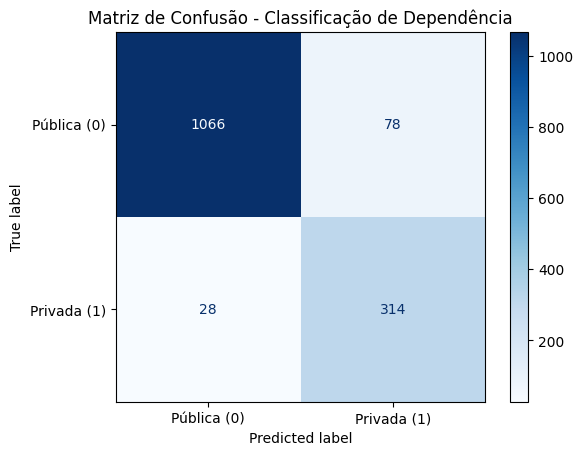


Porte (QT_MAT_BAS) por classe:
                 mean  median
target_privada               
0               270.6   175.5
1               211.5   131.0

Proporção de escolas RURAIS por classe:
target_privada
0    0.362
1    0.016
Name: TP_LOCALIZACAO, dtype: float64


,Pública,Privada,diferenca
IN_ALIMENTACAO,0.995,0.329,-0.666
IN_ORGAO_CONSELHO_ESCOLAR,0.788,0.263,-0.525
IN_ORGAO_NENHUM,0.128,0.625,0.497
IN_PARQUE_INFANTIL,0.293,0.746,0.453
IN_BANHEIRO_EI,0.327,0.748,0.421
IN_ESGOTO_REDE_PUBLICA,0.489,0.887,0.398
IN_ESGOTO_FOSSA,0.506,0.123,-0.383
IN_COMUM_CRECHE,0.354,0.732,0.378
IN_MATERIAL_PED_INFANTIL,0.464,0.834,0.370
TP_AEE,0.365,0.020,-0.345


In [18]:
# predições no conjunto de teste
y_pred = gnb.predict(X_test_scaled)

print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pública (0)', 'Privada (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - Classificação de Dependência')
plt.show()

print("\nPorte (QT_MAT_BAS) por classe:")
print(base_consolidada.groupby('target_privada')['QT_MAT_BAS'].agg(['mean', 'median']).round(1))

print("\nProporção de escolas RURAIS por classe:")
print(base_consolidada.groupby('target_privada')['TP_LOCALIZACAO'].apply(lambda s: (s == 2).mean()).round(3))

# média de cada variável por classe aprendida pelo Naive Bayes
medias = pd.DataFrame(gnb.theta_, index=['Pública', 'Privada'], columns=colunas_finais).T
medias['diferenca'] = (medias['Privada'] - medias['Pública']).round(3)
display(medias.round(3).sort_values('diferenca', key=abs, ascending=False))